### Xgboost from PCA, yeo v4 dataset 
### Stopping early, with 30% test set, 20% validation set and 50% training set

In [95]:
import pandas as pd
from sklearn.model_selection import train_test_split, GroupShuffleSplit, RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import json
import os
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import random as rd
from datetime import datetime

In [96]:
note_for_docs = "30% test, 60% train, 10% validation."

In [97]:
def log_experiment(params, accuracy, cm_normalized, labels, filepath="experiment_logs.jsonl", mode="jsonl"):
    """
    Logs hyperparameter tuning runs to either JSON Lines or CSV.
    
    cm_normalized: numpy array from confusion_matrix(y_test, y_pred, normalize='true')
    labels: list/array of class names from le.classes_
    """
    timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    
    if mode == "jsonl":
        # Create dictionary representation of the confusion matrix (actual -> predicted -> %)
        cm_dict = {
            actual: {pred: round(float(cm_normalized[i, j] * 100), 2) 
                     for j, pred in enumerate(labels)}
            for i, actual in enumerate(labels)
        }
        
        entry = {
            "timestamp": timestamp,
            "accuracy": round(float(accuracy), 4),
            "hyperparameters": params,
            "confusion_matrix_pct": cm_dict,
            "note": note_for_docs
        }
        
        with open(filepath, "a") as f:
            f.write(json.dumps(entry) + "\n")
        print(f"Logged run to {filepath} (JSONL)")

    elif mode == "csv":
        # Flatten parameters and confusion matrix entries into a single dictionary row
        row = {
            "timestamp": timestamp,
            "accuracy": round(float(accuracy), 4),
            **{f"param_{k}": v for k, v in params.items()}
        }
        
        # Flatten confusion matrix percentages: cm_<actual>_<predicted>
        for i, actual in enumerate(labels):
            for j, pred in enumerate(labels):
                col_name = f"cm_{actual}_{pred}"
                row[col_name] = round(float(cm_normalized[i, j] * 100), 2)
        
        df_row = pd.DataFrame([row])
        file_exists = os.path.isfile(filepath)
        df_row.to_csv(filepath, mode="a", index=False, header=not file_exists)
        print(f"Logged run to {filepath} (CSV)")

In [ ]:
param = {
    'learning_rate': 0.01,
    'max_depth': 3,
    'n_estimators': 200,
    'early_stopping_rounds': 60,
    'subsample': 1,
    'colsample_bytree': 1,
    'min_child_weight': 2,
    'objective': 'binary:logistic',
    'gamma': 0,
    'random_state': 69
}

In [99]:
df = pd.read_csv('../dataset/full_v4_pca_yeo-johnson_2026-10-01_17-12-09.csv')
df.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC81,PC82,PC83,PC84,PC85,PC86,PC87,PC88,subject,Activity
0,-11.552402,1.723772,2.346996,8.533060,-0.224374,-0.067294,3.819454,0.662042,0.824410,-0.386227,...,0.292498,-0.658183,-0.735144,-0.213249,-0.982556,0.310451,0.792838,0.842045,1,STANDING
1,-2.264507,-3.108915,-1.432700,1.125572,-1.048343,-1.499094,3.517914,-0.030733,-0.091470,-2.269275,...,-0.255876,0.840966,-0.407073,-0.332361,0.441930,-0.713658,0.736757,-1.994001,3,STANDING
2,-9.460683,-0.892321,-2.123310,4.550429,0.803871,-0.732076,0.058888,0.781478,-0.020931,-1.728804,...,-0.736957,0.012483,0.212978,-0.254274,0.252554,-0.334354,0.102270,-0.052334,1,STANDING
3,-7.218036,-4.732282,-0.502230,3.718350,0.799629,-1.428685,2.465013,2.737118,-0.436518,2.877746,...,0.540501,0.424261,0.316522,0.264829,-0.254833,-1.643265,-0.433616,0.088936,3,STANDING
4,-9.059873,0.208189,-2.464919,4.580265,-0.269384,-0.608020,0.393577,1.354276,-0.541040,-0.308421,...,0.575412,0.008193,0.173754,0.133451,1.348293,-0.324317,0.221444,-0.397093,1,STANDING


In [100]:
le = LabelEncoder()
df['Activity_encoded'] = le.fit_transform(df['Activity'])
df = df.drop(columns=['Activity'])

In [101]:
# 1. First split: 30% Test, 70% Temporary (Train + Val)
gss_test = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=69)
temp_idx, test_idx = next(gss_test.split(df, groups=df['subject']))

df_temp = df.iloc[temp_idx].copy()
df_test = df.iloc[test_idx].copy()

# 2. Second split on temp set: 10% Val / 70% total
gss_val = GroupShuffleSplit(n_splits=1, test_size=0.1428, random_state=42)
train_idx, val_idx = next(gss_val.split(df_temp, groups=df_temp['subject']))

df_train = df_temp.iloc[train_idx].copy()
df_val = df_temp.iloc[val_idx].copy()

# Separate features (X) and target (y)
X_train, y_train = df_train.drop(columns=['subject', 'Activity_encoded']), df_train['Activity_encoded']
X_val, y_val     = df_val.drop(columns=['subject', 'Activity_encoded']), df_val['Activity_encoded']
X_test, y_test   = df_test.drop(columns=['subject', 'Activity_encoded']), df_test['Activity_encoded']

# Verify subject isolation
print(f"Train subjects ({len(df_train['subject'].unique())}): {set(df_train['subject'].unique())}")
print(f"Val subjects   ({len(df_val['subject'].unique())}): {set(df_val['subject'].unique())}")
print(f"Test subjects  ({len(df_test['subject'].unique())}): {set(df_test['subject'].unique())}")

Train subjects (18): {np.int64(2), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(17), np.int64(18), np.int64(19), np.int64(21), np.int64(24), np.int64(28), np.int64(29), np.int64(30)}
Val subjects   (3): {np.int64(1), np.int64(27), np.int64(23)}
Test subjects  (9): {np.int64(3), np.int64(9), np.int64(14), np.int64(15), np.int64(16), np.int64(20), np.int64(22), np.int64(25), np.int64(26)}


In [102]:
model = xgb.XGBClassifier(**param)

model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=True
)
y_pred = model.predict(X_test)

y_decoded = le.inverse_transform(y_test)
y_pred_decoded = le.inverse_transform(y_pred)
y_decoded = pd.DataFrame(y_decoded)
y_pred_decoded = pd.DataFrame(y_pred_decoded)

print("--- Classification Report (Unseen Subjects) ---")
print(classification_report(y_decoded, y_pred_decoded))

[0]	validation_0-mlogloss:1.77172	validation_1-mlogloss:1.77077
[1]	validation_0-mlogloss:1.75779	validation_1-mlogloss:1.75599
[2]	validation_0-mlogloss:1.74417	validation_1-mlogloss:1.74151
[3]	validation_0-mlogloss:1.73075	validation_1-mlogloss:1.72726
[4]	validation_0-mlogloss:1.71758	validation_1-mlogloss:1.71337
[5]	validation_0-mlogloss:1.70472	validation_1-mlogloss:1.70001
[6]	validation_0-mlogloss:1.69204	validation_1-mlogloss:1.68691
[7]	validation_0-mlogloss:1.67968	validation_1-mlogloss:1.67376
[8]	validation_0-mlogloss:1.66750	validation_1-mlogloss:1.66080
[9]	validation_0-mlogloss:1.65554	validation_1-mlogloss:1.64821
[10]	validation_0-mlogloss:1.64373	validation_1-mlogloss:1.63555
[11]	validation_0-mlogloss:1.63212	validation_1-mlogloss:1.62313
[12]	validation_0-mlogloss:1.62078	validation_1-mlogloss:1.61095
[13]	validation_0-mlogloss:1.60951	validation_1-mlogloss:1.59881
[14]	validation_0-mlogloss:1.59847	validation_1-mlogloss:1.58737
[15]	validation_0-mlogloss:1.58765	

Logged run to ../dataset/experiment_logs.jsonl (JSONL)


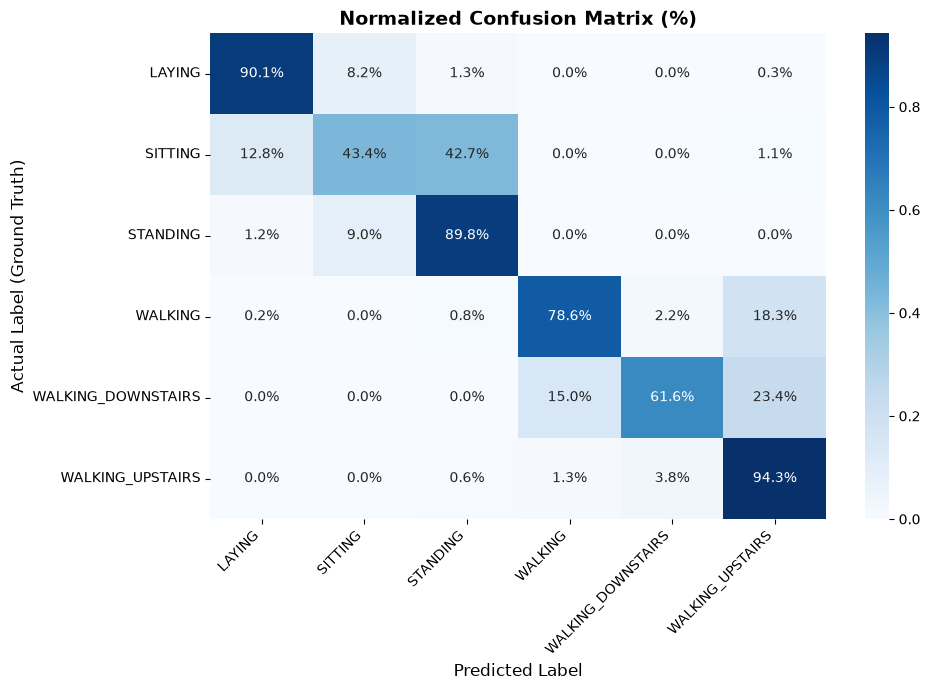

In [103]:
# Compute normalized matrix (percentages along rows)
cm_normalized = confusion_matrix(y_test, y_pred, normalize='true')

# Compute metrics
accuracy = accuracy_score(y_test, y_pred)
cm_normalized = confusion_matrix(y_test, y_pred, normalize='true')
labels = le.classes_

# Log your experiment (Option 1: JSON Lines)
log_experiment(
    params=param,
    accuracy=accuracy,
    cm_normalized=cm_normalized,
    labels=labels,
    filepath="../dataset/experiment_logs.jsonl",
    mode="jsonl"
)

# Get activity labels in the same order used by LabelEncoder
labels = le.classes_

plt.figure(figsize=(10, 7))
sns.heatmap(
    cm_normalized, 
    annot=True, 
    fmt='.1%',              # Format as percentage (e.g., 70.2%)
    cmap='Blues', 
    xticklabels=labels, 
    yticklabels=labels
)

plt.title('Normalized Confusion Matrix (%)', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Label (Ground Truth)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()